In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv(r"./RegData.csv")

print(df.columns)
print(df.shape)
df.head()

Index(['StID', 'SAT', 'GPA'], dtype='str')
(84, 3)


,StID,SAT,GPA
0,101,1355,3.42
1,102,1391,3.48
2,103,1170,2.91
3,104,1357,3.41
4,105,1326,3.28


In [6]:
y1 = df['GPA']
x1 = df['SAT']

In [7]:
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(x1, y1)

Text(0, 0.5, 'GPA')

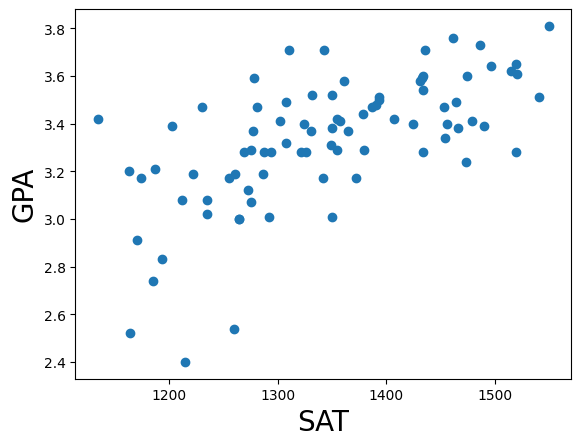

In [8]:
plt.scatter(x1, y1) 
plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)

Text(0.5, 1.0, 'Regression Analysis')

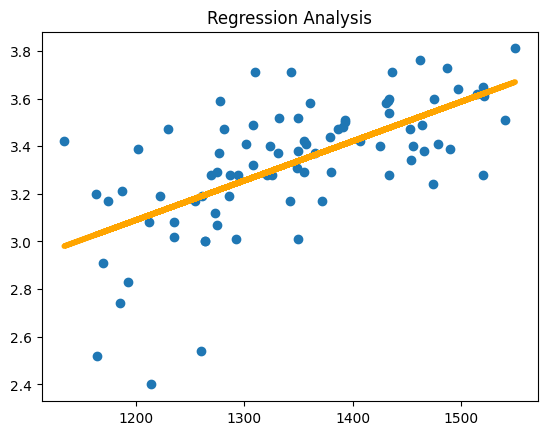

In [9]:
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(x1, y1)

fig = plt.figure()
plt.scatter(x1, y1)

y2 = slope * x1 + intercept

fig = plt.plot(x1, y2, lw=4, c='orange')

plt.title("Regression Analysis")

## Find the Predicted value of unseen data
#### using y2 = slopx1 + intercept

In [10]:
givenSAT = 1450
predGPA = slope*givenSAT + intercept
predGPA

np.float64(3.503631997341267)

In [11]:
y_pred = slope * x1 + intercept

### Actual Vs Predicted

In [12]:
df_p = pd.DataFrame({
    "ActualGPA": y1,
    "PredictGPA": y_pred
})
df_p.head()

,ActualGPA,PredictGPA
0,3.42,3.346342
1,3.48,3.405946
2,2.91,3.040039
3,3.41,3.349653
4,3.28,3.298327


<Axes: >

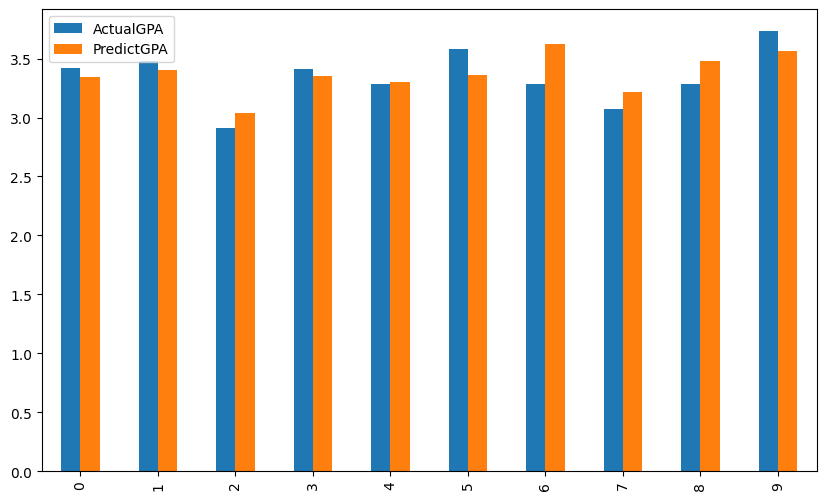

In [13]:
df_p.head(10).plot(kind = "bar", figsize = (10, 6))

In [14]:
df_a_p = pd.DataFrame({**df, "PredictedGPA" : y_pred})
df_a_p.head()

,StID,SAT,GPA,PredictedGPA
0,101,1355,3.42,3.346342
1,102,1391,3.48,3.405946
2,103,1170,2.91,3.040039
3,104,1357,3.41,3.349653
4,105,1326,3.28,3.298327


In [15]:
import seaborn as sns

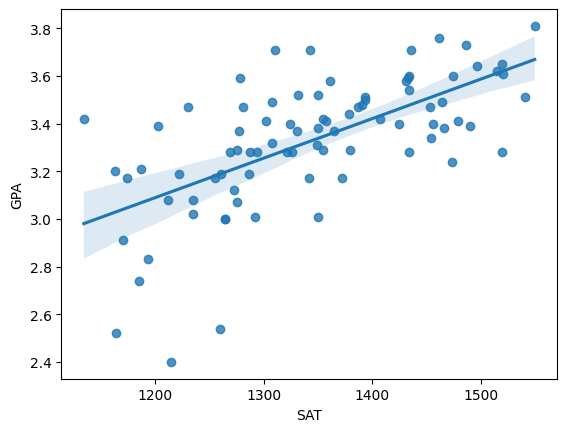

In [16]:
p = sns.regplot(data = df, x = df.SAT, y = df.GPA)

In [17]:
print(df.columns)

Index(['StID', 'SAT', 'GPA'], dtype='str')


<Axes: xlabel='SAT', ylabel='GPA'>

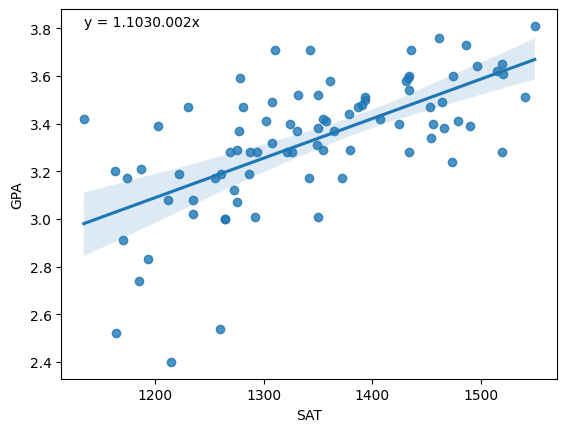

In [18]:
# add regression equation to plot
plt.text(min(df.SAT), max(df.GPA), 'y = ' + str(round(intercept, 3)) + str(round(slope, 3)) + 'x' )

sns.regplot(data=df, x='SAT', y='GPA')

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
x = df.SAT
y = df.GPA

# split data

X_train,X_test,Y_train,Y_test = train_test_split(x,y, test_size= 0.3, random_state=1)


X_train = X_train.to_numpy().reshape(-1, 1)
X_test = X_test.to_numpy().reshape(-1,1)

In [21]:
from sklearn.linear_model import LinearRegression
regsr = LinearRegression()


In [22]:
# fit a model

model = regsr.fit(X_train, Y_train)


In [23]:
# make prediction on test set

y_pred = model.predict(X_test)


In [24]:
y = pd.DataFrame({"Original": Y_test, 'Predicted': y_pred})
y.head()

,Original,Predicted
10,3.01,3.270437
67,3.40,3.527507
59,2.52,3.069796
33,3.71,3.298652
83,3.44,3.406809


<Axes: >

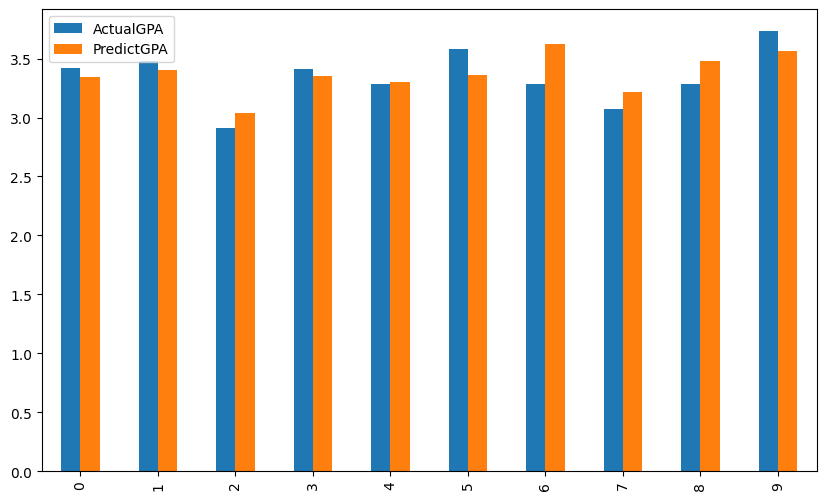

In [25]:
df_p.head(10).plot(kind = "bar", figsize = (10, 6))

### Evaluation Indicator

In [26]:
from sklearn import metrics

In [27]:
print('Evaluation indicators')
print('MAE: \t \t ', metrics.mean_absolute_error(Y_test, y_pred))
print('MSE: \t\t ', metrics.mean_squared_error(Y_test, y_pred))
print('RMSE: \t\t ', metrics.mean_squared_error(Y_test, y_pred)**(0.5))
print('R-Squared: \t ', metrics.r2_score(Y_test, y_pred))

Evaluation indicators
MAE: 	 	  0.2054834292112158
MSE: 		  0.08052728657188303
RMSE: 		  0.28377330137256224
R-Squared: 	  0.3346446677333793


### MAE = 0.2055
#### MAE(Mean Absolute Error) is the average absolute differece between predicted and actual value. SO,on average  the same units as your target

### MSE = 0.0805